Starting load test...
Sending request  1
Sending request  2
Sending request  3
Sending request  4
Sending request  5
Sending request  6
Test completed, generating report...


,total_requests,success_rate,avg_latency,p95_latency,p99_latency,error_distribution
0,6,100.0,127.422492,156.20631,156.452215,{}


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th></th>\n      <th>status</th>\n      <th>latency</th>\n      <th>success</th>\n      <th>error</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <th>0</th>\n      <td>200</td>\n      <td>155.284166</td>\n      <td>True</td>\n      <td>None</td>\n    </tr>\n    <tr>\n      <th>1</th>\n      <td>200</td>\n      <td>120.368242</td>\n      <td>True</td>\n      <td>None</td>\n    </tr>\n    <tr>\n      <th>2</th>\n      <td>200</td>\n      <td>102.151394</td>\n      <td>True</td>\n      <td>None</td>\n    </tr>\n    <tr>\n      <th>3</th>\n      <td>200</td>\n      <td>109.794378</td>\n      <td>True</td>\n      <td>None</td>\n    </tr>\n    <tr>\n      <th>4</th>\n      <td>200</td>\n      <td>120.423079</td>\n      <td>True</td>\n      <td>None</td>\n    </tr>\n  </tbody>\n</table>'

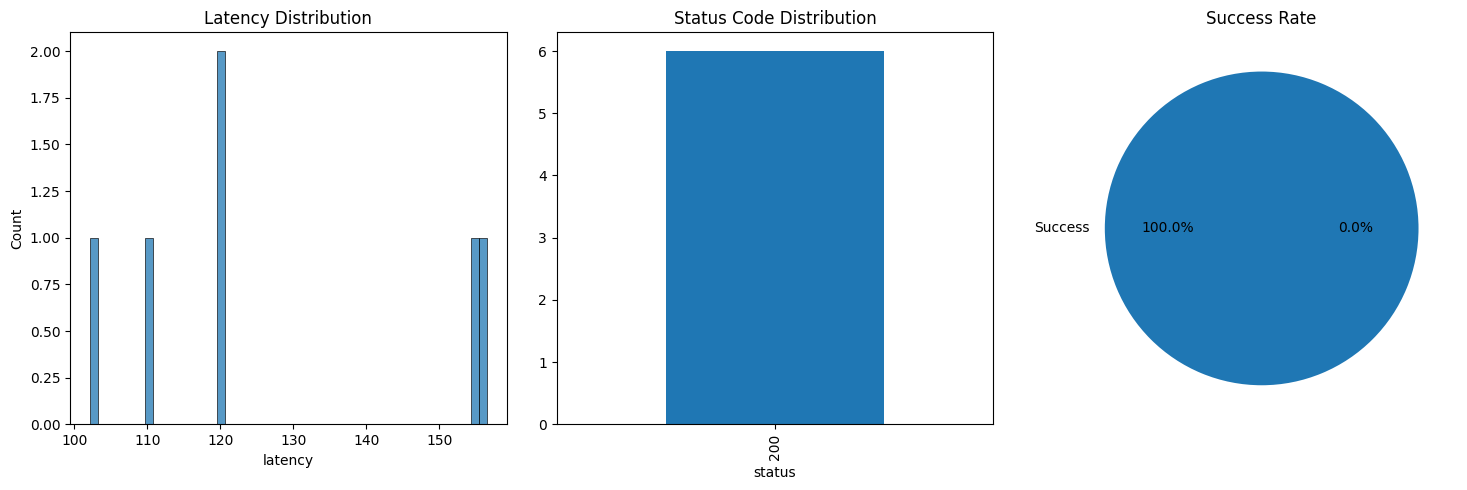

In [1]:
import requests
import json
import pandas as pd
import random
import numpy as np
import datetime
import time
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return super(NumpyEncoder, self).default(obj)

def generate_random_profile(df):
    return {col: random.choice(df[col].unique()) for col in df.columns}

def send_request(url, df):
    try:
        profile = generate_random_profile(df)
        start_time = time.time()
        response = requests.post(
            url,
            headers={"Content-Type": "application/json"},
            data=json.dumps(profile, cls=NumpyEncoder),
            timeout=10
        )
        latency = (time.time() - start_time) * 1000  # ms
        return {
            "status": response.status_code,
            "latency": latency,
            "success": response.status_code == 200,
            "error": None
        }
    except Exception as e:
        return {
            "status": 500,
            "latency": 0,
            "success": 0,
            "error": str(e)
        }

def run_load_test(df, url, max_time=300):
    results = []
    start_time = time.time()
    counter = 0
    with ThreadPoolExecutor(max_workers=50) as executor:
        while (time.time() - start_time) < max_time:
                counter +=1
                print('Sending request ', counter)
                response = send_request(url, df)
                results.append(response)
    
    return pd.DataFrame(results)

def generate_report(results_df):
    report = {
        "total_requests": len(results_df),
        "success_rate": results_df['success'].mean() * 100,
        "avg_latency": results_df['latency'].mean(),
        "p95_latency": np.percentile(results_df['latency'], 95),
        "p99_latency": np.percentile(results_df['latency'], 99),
        "error_distribution": results_df['error'].value_counts().to_dict()
    }
    
    # Визуализации
    plt.figure(figsize=(15, 5))
    
    plt.subplot(131)
    sns.histplot(results_df['latency'], bins=50)
    plt.title('Latency Distribution')
    
    plt.subplot(132)
    results_df['status'].value_counts().plot(kind='bar')
    plt.title('Status Code Distribution')
    
    plt.subplot(133)
    pd.Series([report['success_rate'], 100 - report['success_rate']], 
             index=['Success', 'Error']).plot(kind='pie', autopct='%1.1f%%')
    plt.title('Success Rate')
    
    plt.tight_layout()
    plt.savefig('load_test_report.png')
    
    # HTML отчет
    html_report = f"""
    <html>
        <body>
            <h1>Load Test Report</h1>
            <pre>{pd.DataFrame([report]).to_html()}</pre>
            <h2>Charts</h2>
            <img src="load_test_report.png" width="100%">
        </body>
    </html>
    """
    
    with open("load_test_report.html", "w") as f:
        f.write(html_report)
    
    return report

# Основной код тестирования
df = pd.read_csv(r'data/train_ver2.csv', low_memory=False)
url = "http://localhost:8079/predict"

print("Starting load test...")
results = run_load_test(df, url, max_time=50)

print("Test completed, generating report...")
report = generate_report(results)

# Вывод результатов
display(HTML(pd.DataFrame([report]).to_html()))
display(HTML("<h2>First 5 responses:</h2>"))
display(results.head().to_html())


Starting load test...
Sending request  1
Sending request  2
Sending request  3
Sending request  4
Sending request  5
Sending request  6
Sending request  7
Sending request  8
Sending request  9
Sending request  10
Sending request  11
Sending request  12
Sending request  13
Sending request  14
Sending request  15
Sending request  16
Sending request  17
Sending request  18
Sending request  19
Sending request  20
Sending request  21
Sending request  22
Sending request  23
Sending request  24
Sending request  25
Sending request  26
Sending request  27
Sending request  28
Sending request  29
Sending request  30
Sending request  31
Sending request  32
Sending request  33
Sending request  34
Sending request  35
Sending request  36
Sending request  37
Sending request  38
Sending request  39
Sending request  40
Sending request  41
Sending request  42
Sending request  43
Sending request  44
Sending request  45
Sending request  46
Sending request  47
Sending request  48
Sending request  49
Sending

,total_requests,success_rate,avg_latency,p95_latency,p99_latency,error_distribution
0,92,100.0,135.642915,193.07574,202.75445,{}


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th></th>\n      <th>status</th>\n      <th>latency</th>\n      <th>success</th>\n      <th>error</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <th>0</th>\n      <td>200</td>\n      <td>121.954203</td>\n      <td>True</td>\n      <td>None</td>\n    </tr>\n    <tr>\n      <th>1</th>\n      <td>200</td>\n      <td>112.632275</td>\n      <td>True</td>\n      <td>None</td>\n    </tr>\n    <tr>\n      <th>2</th>\n      <td>200</td>\n      <td>106.167316</td>\n      <td>True</td>\n      <td>None</td>\n    </tr>\n    <tr>\n      <th>3</th>\n      <td>200</td>\n      <td>113.837719</td>\n      <td>True</td>\n      <td>None</td>\n    </tr>\n    <tr>\n      <th>4</th>\n      <td>200</td>\n      <td>108.394146</td>\n      <td>True</td>\n      <td>None</td>\n    </tr>\n  </tbody>\n</table>'

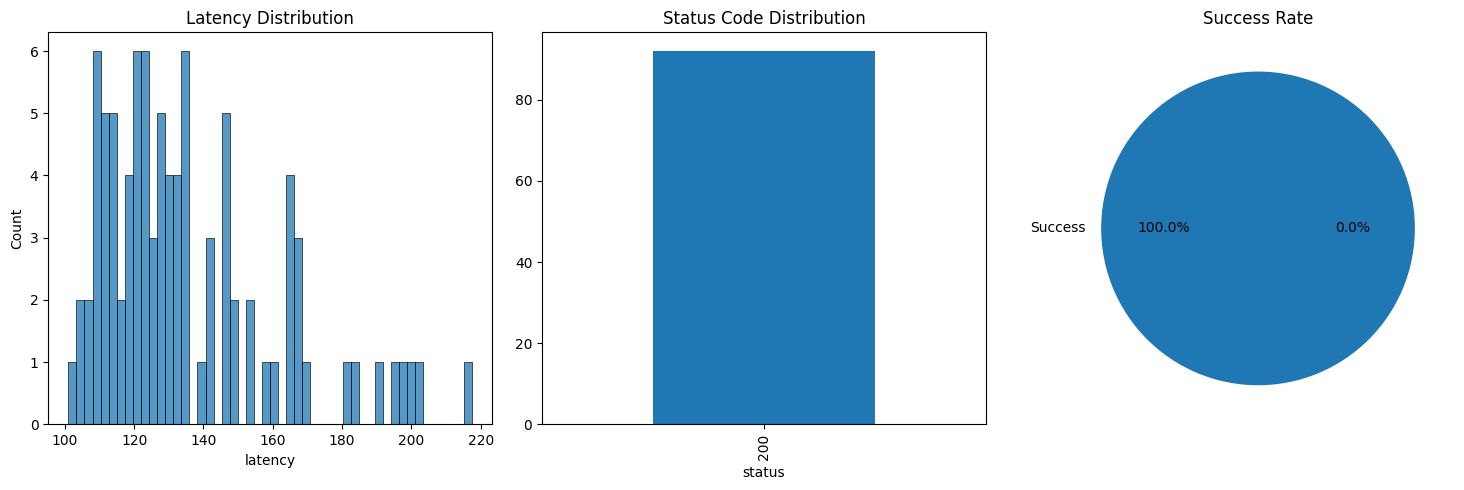

In [22]:
#Если хочешь повторить тест:
url = "http://localhost:8079/predict"
print("Starting load test...")
results = run_load_test(df, url, max_time=505)

print("Test completed, generating report...")
report = generate_report(results)

# Вывод результатов
display(HTML(pd.DataFrame([report]).to_html()))
display(HTML("<h2>First 5 responses:</h2>"))
display(results.head().to_html())
